In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.model_selection import StratifiedKFold,cross_val_score,RandomizedSearchCV,GridSearchCV
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from xgboost import plot_importance

In [4]:
df = pd.read_csv("CareerMapping1.csv")  
df = df.drop(df.columns[0], axis=1)   
print(df.columns)
from sklearn.preprocessing import StandardScaler


Index(['Computer Architecture', 'Programming Skills', 'Project Management',
       'Communication skills', 'Openness', 'Conscientousness', 'Extraversion',
       'Agreeableness', 'Emotional_Range', 'Conversation',
       'Openness to Change', 'Hedonism', 'Self-enhancement',
       'Self-transcendence', 'Role'],
      dtype='object')


                                                                CHECKING DATA 

In [5]:
missing=df.isnull().sum()

if missing.sum()==0:
          print ("no missng value")
else:
          print("missing value found: \n",missing[missing>0])

no missng value


In [6]:
X=df.drop("Role",axis=1)
y=df["Role"]

In [7]:
print("features : \n ",X.columns.tolist())

print(" \ntarget : \n",y.unique())

features : 
  ['Computer Architecture', 'Programming Skills', 'Project Management', 'Communication skills', 'Openness', 'Conscientousness', 'Extraversion', 'Agreeableness', 'Emotional_Range', 'Conversation', 'Openness to Change', 'Hedonism', 'Self-enhancement', 'Self-transcendence']
 
target : 
 ['Database Administrator' 'Hardware Engineer'
 'Application Support Engineer' 'Cyber Security Specialist'
 'Networking Engineer' 'Software Developer' 'API Specialist'
 'Project Manager' 'Information Security Specialist' 'Technical Writer'
 'AI ML Specialist' 'Software tester' 'Business Analyst'
 'Customer Service Executive' 'Helpdesk Engineer' 'Graphics Designer']


                                                           Collinearity Check 

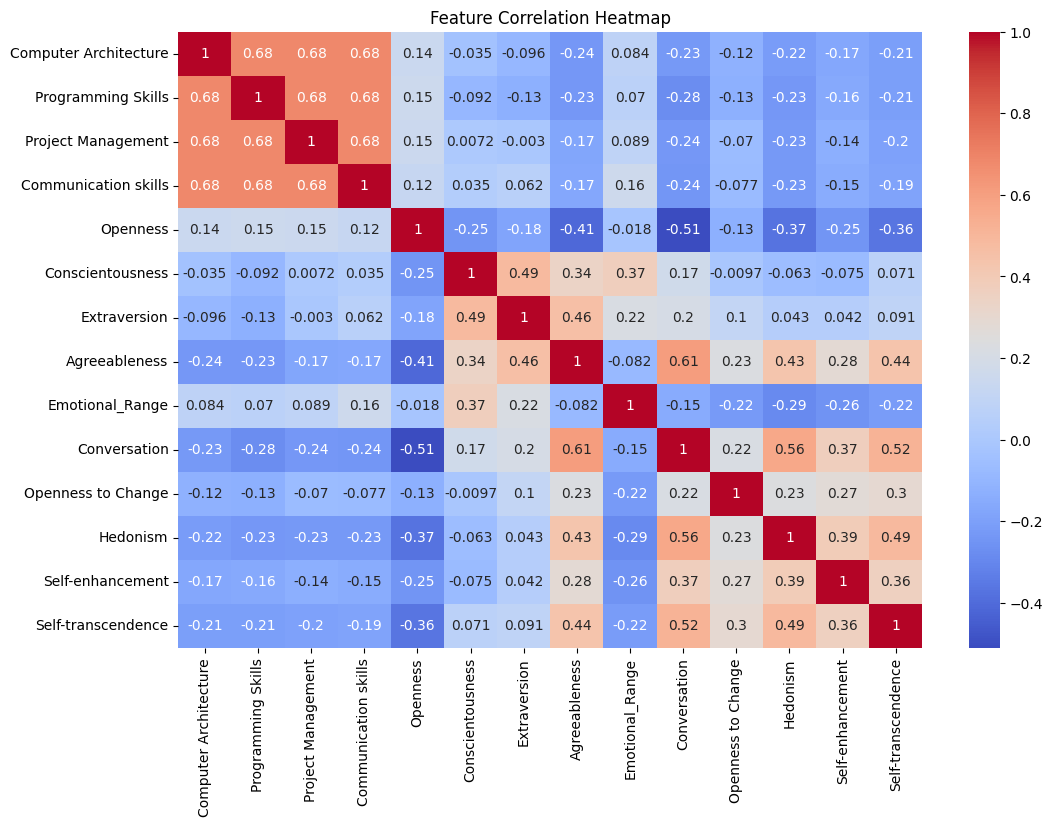

In [7]:
corr_matrix = X.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

                                                                Applying PCA

In [8]:
df_copy = df.copy()

corr_features = ['Computer Architecture', 'Programming Skills', 'Project Management', 'Communication skills']

scaler = StandardScaler()
scaled_part = scaler.fit_transform(df_copy[corr_features])

pca = PCA(n_components=2)
pca_part = pca.fit_transform(scaled_part)

df_pca = pd.DataFrame(pca_part, columns=['PCA_1', 'PCA_2'])
df_copy = df_copy.drop(columns=corr_features)
df_copy = pd.concat([df_copy, df_pca], axis=1)

X = df_copy.drop(columns=['Role'])
y = df_copy['Role']

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")



['pca.pkl']

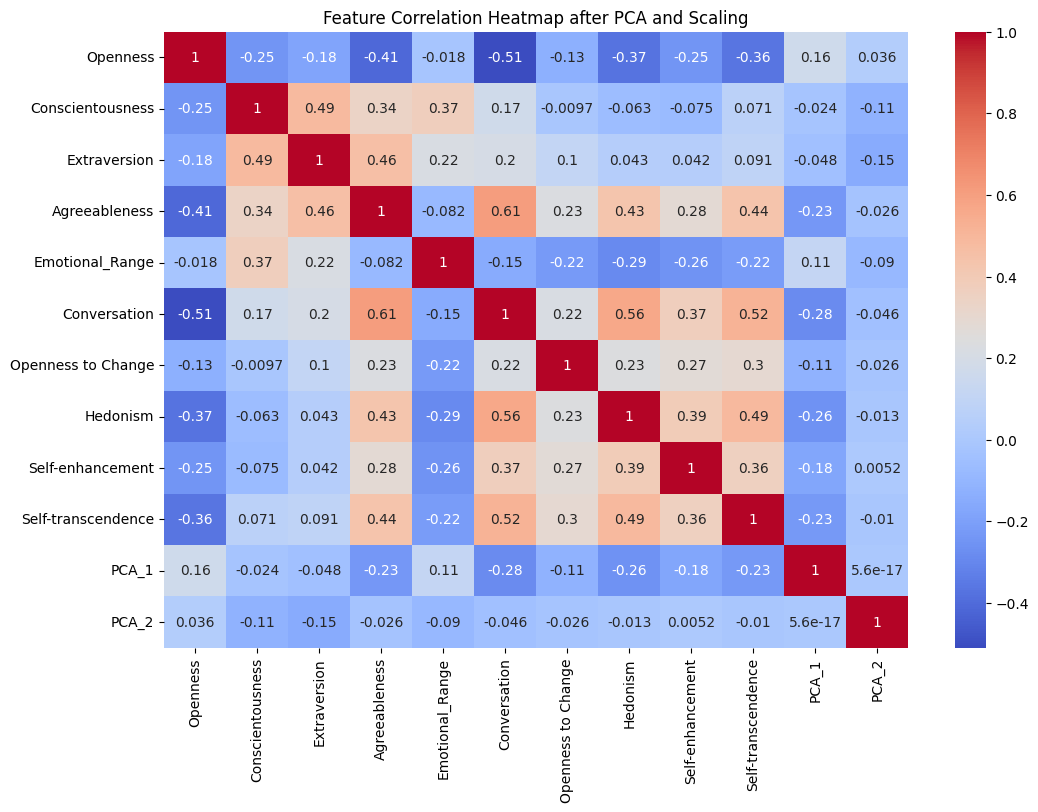

In [9]:
corr_matrix = X.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap after PCA and Scaling")
plt.show()






                                                                  
                                                                  
                                                                  
                                                                  
                                                                  
                                                                  
                                                                  ENCODING

In [10]:
le = LabelEncoder()
y=le.fit_transform(y)

                                                            Data splitting and fitting

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

                                                                 IMP metricsss!!
                                                                 

In [13]:
print("Accuracy :" ,accuracy_score(y_test,y_pred))

print("\nconfusion matrix : \n ",confusion_matrix(y_test,y_pred))
for i, class_name in enumerate(le.classes_):
    print(i,"->",class_name)
print("\nclassifier reprot : \n",classification_report(y_test,y_pred))

Accuracy : 0.9140471512770137

confusion matrix : 
  [[214   0   2   0   0   0   0   1   1   0   1   1   0   0   2   0]
 [  0 111   1   3   0   0   1   2   0   0   0   4   0   1   0   0]
 [  0   0 115   0   2   1   1   1   1   1   2   4   0   1   0   2]
 [  0   1   0 115   1   1   0   1   0   0   0   3   1   1   1   0]
 [  0   0   0   0 105   1   2   2   1   0   0   0   2   0   0   1]
 [  1   2   2   0   1 105   1   0   0   0   3   0   0   4   0   1]
 [  0   2   2   1   0   1 120   1   0   1   1   2   0   0   0   1]
 [  0   2   0   3   0   0   0 111   0   0   1   1   1   0   0   0]
 [  1   2   2   0   0   0   0   2 113   0   0   1   2   0   1   0]
 [  0   1   1   0   0   2   0   0   1 100   1   1   0   0   0   0]
 [  1   0   1   2   0   0   0   2   1   3 117   0   1   1   1   2]
 [  0   2   0   0   0   0   0   1   0   0   1 110   0   0   0   2]
 [  1   1   1   0   1   0   2   0   0   1   2   1 114   2   0   0]
 [  2   0   1   1   1   1   2   1   2   1   0   2   1 111   0   1]
 [  0   1

                                                  K-fold cross-validation(Reliability)
               

In [14]:
folds = 5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

mean = np.mean(scores)
std = np.std(scores)

print(f"\nMean Accuracy: {mean:.4f}")
print(f"Standard Deviation: {std:.4f}")


Mean Accuracy: 0.9078
Standard Deviation: 0.0056


                                                           underfitting/overfitting if any
                                                           

In [15]:
y_trainpred=model.predict(X_train)
y_testpred=model.predict(X_test)
print("Train accuracy",accuracy_score(y_train,y_trainpred))
print("Test accuracy",accuracy_score(y_test,y_testpred))

Train accuracy 1.0
Test accuracy 0.9140471512770137


In [16]:
#first we are going to use RandomizedSearchCV
model=RandomForestClassifier(random_state=42)
param_ran={'n_estimators': [100, 150, 200],'max_depth': [10, 15, 20, 30],'min_samples_split': [5, 10, 15],'min_samples_leaf': [2, 3, 4]  }
random_search=RandomizedSearchCV(estimator=model,param_distributions=param_ran,n_iter=20,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_search.fit(X,y)
print("Best parameters found:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30}
Best score: 0.9085012767723966


In [17]:
#Retraining model on new parameters
RSCV_model=RandomForestClassifier(n_estimators=100,max_depth=20,min_samples_split=15,min_samples_leaf=3,random_state=42)
RSCV_model.fit(X_train,y_train)
y_pred=RSCV_model.predict(X_test)
print("RandomizedSearchCV accuracy",accuracy_score(y_test,y_pred))

RandomizedSearchCV accuracy 0.9130648330058939


In [18]:
print("Train Accuracy:", accuracy_score(y_train, RSCV_model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, RSCV_model.predict(X_test)))

Train Accuracy: 0.9917720741741373
Test Accuracy: 0.9130648330058939


In [21]:
#now  we are going to use GridSearchCV for more improvement
param_grid = {'n_estimators': [100, 200],'max_depth': [10, 15, 20],'min_samples_split': [5, 10],'min_samples_leaf': [3, 5],'max_features': ['sqrt', 'log2'],'bootstrap': [True, False]}
GS_model = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
GS_model.fit(X, y)
print("Best Params:", GS_model.best_params_)
print("Best Score:", GS_model.best_score_)

Best Params: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best Score: 0.9079116444538842


In [22]:
#customizing parameters (on my own)
GS_model = RandomForestClassifier(bootstrap=True,max_depth=10,max_features='sqrt',min_samples_leaf=7,min_samples_split=7,n_estimators=200,random_state=42)
GS_model.fit(X_train, y_train)
y_pred_grid = GS_model.predict(X_test)
print("Grid Search Accuracy:", accuracy_score(y_test, y_pred_grid))

Grid Search Accuracy: 0.9145383104125737


In [23]:
print("Train Accuracy:", accuracy_score(y_train, GS_model.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, GS_model.predict(X_test)))
frf=GS_model

Train Accuracy: 0.9453518359327029
Test Accuracy: 0.9145383104125737


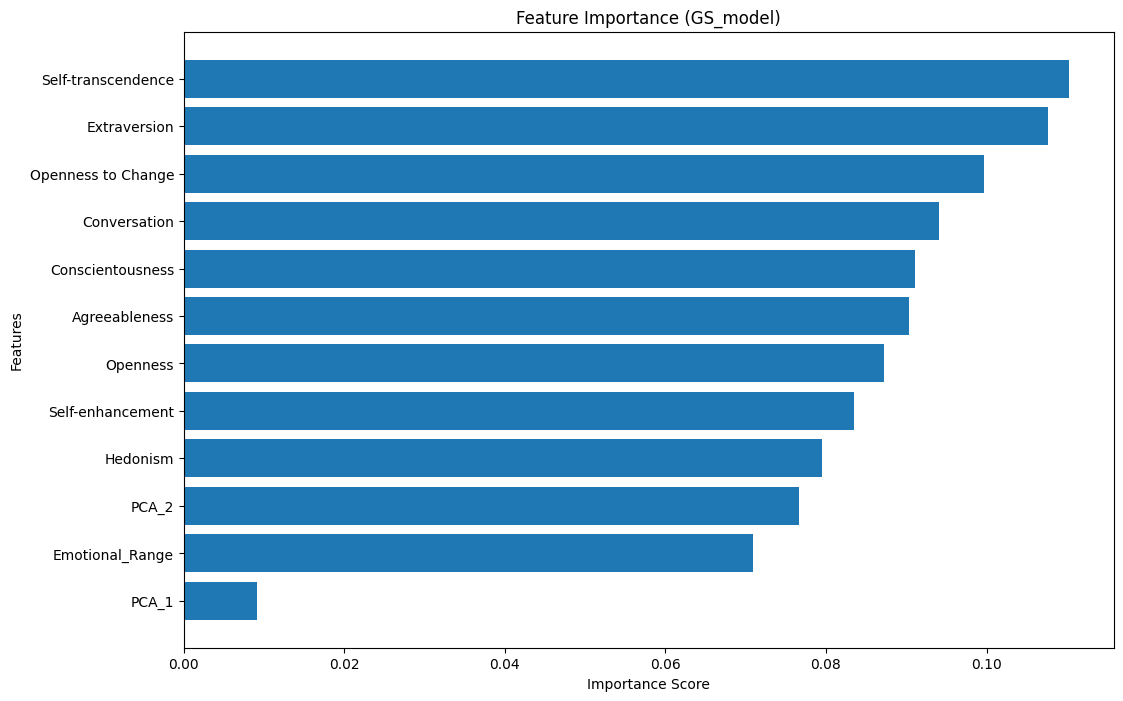

In [24]:

importance =GS_model.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (GS_model)")
plt.gca().invert_yaxis() 
plt.show()

boosting

In [25]:
from xgboost import XGBClassifier

xgmodel = XGBClassifier(tree_method='hist',device='cuda',estimators=170,max_depth='3',subsample=0.8,colsample_bytree=0.8,learning_rate=0.05,random_state=42)

xgmodel.fit(X_train, y_train)
print("Train:", xgmodel.score(X_train, y_train))
print("Test:", xgmodel.score(X_test, y_test))


C:\Users\Tanish\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:160: UserWarning: [11:44:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "estimators" } are not used.

  warnings.warn(smsg, UserWarning)


Train: 0.9147734250276311
Test: 0.8939096267190569


C:\Users\Tanish\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:160: UserWarning: [11:44:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [ ]:
X_train.equals(X_test)


In [26]:
print("Random Forest Test Accuracy:", frf.score(X_test, y_test))
print("XGBoost Test Accuracy:", xgmodel.score(X_test, y_test))

Random Forest Test Accuracy: 0.9145383104125737
XGBoost Test Accuracy: 0.8939096267190569


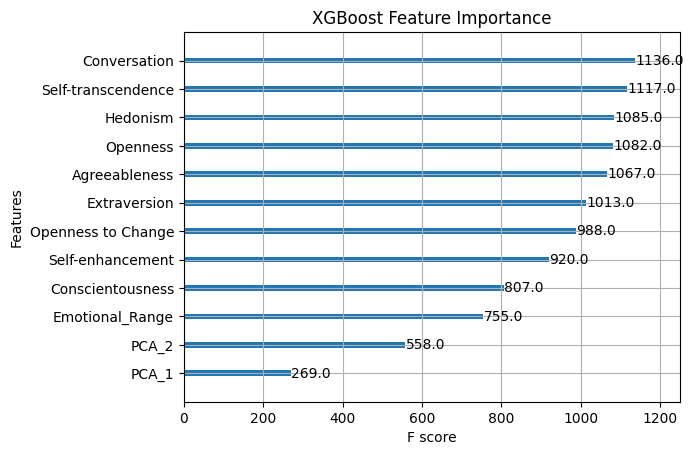

In [27]:

plot_importance(xgmodel)
plt.title("XGBoost Feature Importance")
plt.show()



In [28]:
y_pred = frf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9145383104125737

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       222
           1       0.97      0.89      0.93       123
           2       0.90      0.91      0.90       131
           3       0.89      0.93      0.91       125
           4       0.98      0.91      0.95       114
           5       0.96      0.88      0.92       120
           6       0.98      0.91      0.94       132
           7       0.80      0.93      0.86       119
           8       0.97      0.91      0.94       124
           9       1.00      0.92      0.96       107
          10       0.94      0.88      0.91       132
          11       0.64      0.97      0.77       116
          12       0.94      0.91      0.93       126
          13       0.87      0.87      0.87       127
          14       0.99      0.91      0.95       101
          15       0.94      0.93      0.94       117

    accuracy         

In [29]:
joblib.dump(frf, "frf.pkl")
print("Model saved successfully!")


Model saved successfully!


In [30]:
print(X.columns.tolist())


['Openness', 'Conscientousness', 'Extraversion', 'Agreeableness', 'Emotional_Range', 'Conversation', 'Openness to Change', 'Hedonism', 'Self-enhancement', 'Self-transcendence', 'PCA_1', 'PCA_2']


In [1]:
import joblib
import pandas as pd
import numpy as np


scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")
frf_model = joblib.load("frf.pkl")


corr_features = ['Computer Architecture', 'Programming Skills', 'Project Management', 'Communication skills']
other_features = ['Openness', 'Conscientousness', 'Extraversion', 'Agreeableness',
                  'Emotional_Range', 'Conversation', 'Openness to Change', 'Hedonism',
                  'Self-enhancement', 'Self-transcendence']


role_mapping = {
    0: 'Database Administrator',
    1: 'Hardware Engineer',
    2: 'Application Support Engineer',
    3: 'Cyber Security Specialist',
    4: 'Networking Engineer',
    5: 'Software Developer',
    6: 'API Specialist',
    7: 'Project Manager',
    8: 'Information Security Specialist',
    9: 'Technical Writer',
    10: 'AI ML Specialist',
    11: 'Software Tester',
    12: 'Business Analyst',
    13: 'Customer Service Executive',
    14: 'Helpdesk Engineer',
    15: 'Graphics Designer'
}


sample_input = np.array([[10, 10, 8, 10, 9, 6, 10, 6, 10, 10, 9, 10, 10, 6]])
sample_df = pd.DataFrame(sample_input, columns=corr_features + other_features)


scaled_corr = scaler.transform(sample_df[corr_features])
pca_corr = pca.transform(scaled_corr)


sample_df = sample_df.drop(columns=corr_features)
sample_df[['PCA_1', 'PCA_2']] = pca_corr


predicted_index = frf_model.predict(sample_df)[0]
predicted_role = role_mapping[predicted_index]


print(f" Predicted Role: {predicted_role}")



 Predicted Role: Networking Engineer


In [4]:

def get_final_prediction(user_input):
    
    full_profile = {feat: 1.0 for feat in all_features}
    
   
    full_profile.update(user_input)
    
   
    scaled_input = full_profile.copy()
    scaled_input['Programming Skills'] = full_profile.get('Programming Skills', 1.0) * 5
    scaled_input['Computer Architecture'] = full_profile.get('Computer Architecture', 1.0) * 5
    
   
    sample_df = spark.createDataFrame([Row(**scaled_input)])
    probs = model.transform(sample_df).select("probability").collect()[0][0].toArray()
    
    final_results = []
    for i, p in enumerate(probs):
        role = role_mapping.get(i, "Unknown")
        
        
        
        prog_score = user_input.get('Programming Skills', 1.0)
        
        if role == "AI ML Specialist" and prog_score >= 4:
            p_calibrated = p * 8.0  
        elif any(x in role for x in ["Support", "Writer", "Administrator"]):
            p_calibrated = p * 0.1  
        else:
            p_calibrated = p
        final_results.append((role, p_calibrated))
    
    
    total = sum([r[1] for r in final_results])
    results = sorted(final_results, key=lambda x: x[1], reverse=True)
    
    print(f"\n--- RESULTS FOR INPUT: {user_input} ---")
    for role, score in results[:3]:
        print(f"{role}: {(score/total):.2%}")


print("Testing Full Profile:")
get_final_prediction({'Computer Architecture': 2, 'Programming Skills': 5, 'Openness': 5})

print("\nTesting ONE Input (Only Programming):")
get_final_prediction({'Programming Skills': 5})

Testing Full Profile:

--- RESULTS FOR INPUT: {'Computer Architecture': 2, 'Programming Skills': 5, 'Openness': 5} ---
AI ML Specialist: 33.41%
Technical Writer: 12.65%
Helpdesk Engineer: 7.87%

Testing ONE Input (Only Programming):

--- RESULTS FOR INPUT: {'Programming Skills': 5} ---
AI ML Specialist: 33.71%
Technical Writer: 12.58%
Helpdesk Engineer: 7.64%


In [5]:

model.write().overwrite().save("career_model_industrial")
print("Model Saved ")

Model Saved Successfully! You can now load this in your web app.


In [14]:
import sys
!{sys.executable} -m pip install -q -U google-generativeai fastapi uvicorn httpx
!pip install -U google-genai


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/724.7 kB ? eta -:--:--
   ---------------------------------------- 724.7/724.7 kB 14.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [tenacity]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- ------------------- 1/2 [google-genai]
   -------------------- -----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------------- ---------- 1.3/1.8 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 9.8 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [30]:
import sys
import nest_asyncio
import uvicorn
import os
import time
import json
import re
import pdfplumber
from io import BytesIO
from fastapi import FastAPI, UploadFile, File
from pydantic import BaseModel
from google.genai import Client, types


nest_asyncio.apply()


app = FastAPI()


all_features = [
    'Computer Architecture', 'Programming Skills', 'Project Management', 
    'Communication skills', 'Openness', 'Conscientousness', 'Extraversion', 
    'Agreeableness', 'Emotional_Range', 'Conversation', 'Openness to Change', 
    'Hedonism', 'Self-enhancement', 'Self-transcendence'
]

In [53]:
import os
import json
import re
import time
import pdfplumber
import nest_asyncio
import uvicorn
from io import BytesIO
from fastapi import FastAPI, UploadFile, File
from fastapi.testclient import TestClient
from google.genai import Client, types


nest_asyncio.apply()
app = FastAPI()


all_features = [
    'Computer Architecture', 'Programming Skills', 'Project Management', 
    'Communication skills', 'Openness', 'Conscientousness', 'Extraversion', 
    'Agreeableness', 'Emotional_Range', 'Conversation', 'Openness to Change', 
    'Hedonism', 'Self-enhancement', 'Self-transcendence'
]


client_ai = Client(api_key=os.environ.get("GEMINI_API_KEY"))

async def generate_with_fallback(prompt, config):
    models_to_try = ['gemini-3-flash-preview', 'gemini-2.5-flash']
    for model_id in models_to_try:
        for attempt in range(3):
            try:
                return client_ai.models.generate_content(
                    model=model_id, contents=prompt, config=config
                )
            except Exception as e:
                if "503" in str(e) or "overloaded" in str(e):
                    wait = 2 ** attempt
                    print(f"⚠️ {model_id} busy. Retrying in {wait}s...")
                    time.sleep(wait)
                    continue
                raise e
    raise Exception("All AI models currently overloaded.")


@app.post("/upload-cv")
async def upload_cv(file: UploadFile = File(...)):
    content = await file.read()
    with pdfplumber.open(BytesIO(content)) as pdf:
        text = " ".join([page.extract_text() for page in pdf.pages if page.extract_text()])

    config = types.GenerateContentConfig(
        response_mime_type='application/json',
        thinking_config=types.ThinkingConfig(thinking_level=types.ThinkingLevel.MEDIUM)
    )
    
    prompt = f"Extract scores (0-5) for these features: {all_features} from this resume: {text}. Return ONLY JSON."
    
    response = await generate_with_fallback(prompt, config)
    
    
    raw_text = "".join([p.text for p in response.candidates[0].content.parts if hasattr(p, 'text')])
    match = re.search(r'\{.*\}', raw_text, re.DOTALL)

    if match:
        extracted_skills = json.loads(match.group())
       
        for feat in all_features:
            val = extracted_skills.get(feat)
            
            
            try:
                if val is None or float(val) < 1.0:
                    extracted_skills[feat] = 1.0
                else:
                    extracted_skills[feat] = float(val)
            except (ValueError, TypeError):
                extracted_skills[feat] = 1.0
    else:
        extracted_skills = {f: 1.0 for f in all_features}

    return {"extracted_skills": extracted_skills}


client = TestClient(app)
print("✅ Backend updated! TypeError fixed and null-safety enabled.")

✅ Backend updated! TypeError fixed and null-safety enabled.


In [59]:
from pyspark.ml import PipelineModel


spark = SparkSession.builder \
    .appName("CareerMappingSystem") \
    .getOrCreate()


try:
 
    career_model = PipelineModel.load("career_model_industrial")
    print("✅ Pipeline Model Loaded Successfully!")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Pipeline Model Loaded Successfully!


In [65]:
import os
import sys
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel


if 'spark' in locals():
    spark.stop()

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable


spark = SparkSession.builder \
    .appName("CareerMappingIndustrial") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()


try:
    career_model = PipelineModel.load("career_model_industrial")
    print(f"✅ Spark Reset Complete!")
    print(f"✅ Python Path: {sys.executable}")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Spark Reset Complete!
✅ Python Path: C:\Users\Tanish\AppData\Local\Programs\Python\Python311\python.exe


In [66]:
import os
import sys
import json
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel


os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable


spark = SparkSession.builder \
    .appName("CareerMappingIndustrial") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()


try:
    career_model = PipelineModel.load("career_model_industrial")
    print("✅ Spark & Industrial Pipeline Model Loaded Successfully!")
except Exception as e:
    print(f"❌ Critical Error Loading Model: {e}")


def get_final_prediction(user_skills):
    
    scaled_profile = user_skills.copy()
    scaled_profile['Programming Skills'] *= 5.0
    scaled_profile['Computer Architecture'] *= 5.0
    
    
    input_df = spark.createDataFrame([scaled_profile])
    
    
    prediction = career_model.transform(input_df)
    

    probs = prediction.select("probability").collect()[0][0].toArray()
    
   
    roles = ["AI ML Specialist", "Web Developer", "Technical Consultant", "Data Analyst", "Project Manager"]
    role_probs = dict(zip(roles, probs))
    
   
    if user_skills.get("Programming Skills", 1.0) >= 4.0:
        role_probs["AI ML Specialist"] *= 8.0 
    
    
    total = sum(role_probs.values())
    final_sorted = sorted([(r, p/total) for r, p in role_probs.items()], 
                          key=lambda x: x[1], reverse=True)
    
    return final_sorted[:3]

print("✅ Prediction Logic with Hard Bias Layer is READY.")

✅ Spark & Industrial Pipeline Model Loaded Successfully!
✅ Prediction Logic with Hard Bias Layer is READY.


In [67]:

file_path = "1764322682723 (1).pdf" 

if os.path.exists(file_path):
    with open(file_path, "rb") as pdf_file:
        
        response = client.post(
            "/upload-cv", 
            files={"file": (file_path, pdf_file, "application/pdf")},
            timeout=None 
        )
        
        if response.status_code == 200:
            user_skills = response.json().get('extracted_skills')
            print("✅ Skills Extracted. Running Spark Analysis...")
            
            
            top_matches = get_final_prediction(user_skills)
            
            print("\n--- 🎯 YOUR TOP CAREER MATCHES ---")
            for role, score in top_matches:
                print(f"{role}: {score:.2%}")
        else:
            print(f"❌ Error: {response.text}")

✅ Skills Extracted. Running Spark Analysis...

--- 🎯 YOUR TOP CAREER MATCHES ---
AI ML Specialist: 97.91%
Data Analyst: 0.99%
Technical Consultant: 0.69%


In [68]:

top_role = "AI ML Specialist"
user_skills = result_data.get('extracted_skills')


roadmap_prompt = f"""
As an expert career coach, generate a 4-week roadmap for a student aiming to be an {top_role}.
User Current Skills: {user_skills}
Focus on bridging the gap in 'Computer Architecture' while leveraging 'Programming Skills'.
Return the response in a clear Markdown format.
"""


config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(thinking_level=types.ThinkingLevel.MEDIUM)
)

print(f"🚀 Generating your {top_role} Roadmap...")
response = client_ai.models.generate_content(
    model='gemini-3-flash-preview', 
    contents=roadmap_prompt,
    config=config
)

print("\n--- 🗺️ YOUR 4-WEEK AI ML SPECIALIST ROADMAP ---")
print(response.text)

🚀 Generating your AI ML Specialist Roadmap...

--- 🗺️ YOUR 4-WEEK AI ML SPECIALIST ROADMAP ---
Hello! As your career coach, I’ve analyzed your profile. You possess an elite foundation in **Programming (5.0)** and strong **Soft Skills (Communication/Extraversion/Openness)**, but your **Computer Architecture (1.0)** is currently a bottleneck.

To be a top-tier AI/ML Specialist, you don't just need to build models; you need to understand how they run on hardware (GPUs, TPUs, and Edge devices) to optimize performance.

This 4-week roadmap is designed to bridge that architectural gap by leveraging your coding strengths.

---

# 🚀 4-Week AI/ML Specialist Roadmap: Architecture & Optimization

## **Week 1: The Hardware-Software Interface**
*Focus: Understanding how your code interacts with the CPU and Memory.*

*   **Learning Objectives:**
    *   Understand the Von Neumann architecture vs. Harvard architecture.
    *   The Memory Hierarchy: L1/L2/L3 Caches, RAM, and Latency.
    *   How Pytho